In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
import cc3d

Noter:
- Varie n_max med temperatur. x
- Beregn std på mean x
- Højere n_max for lav i 2. type.
- Højere n_max for lav i 1. type.
- Lidt færre temperature?
- Hvad er en anstændig N_site?

In [3]:
# non-numba functions
def count_domain_size(array):
    labels = cc3d.connected_components(array,connectivity=6)
    if array[0]==array[-1]:
        labels[labels == max(labels)] = 1
    sizes = np.bincount(labels)[1:]
    return sizes

In [10]:
import numba as nb
@nb.njit
def delta_E_total(array,nnn_array,i,J=1,h=0,nnn=False):
    N=len(array)
    delta_E = -2*array[i]*(array[(i+1)%N]+array[i-1])
    
    if nnn==True:
        shuffle_index = np.argwhere(nnn_array==i)[0]
        up_index = nnn_array[(shuffle_index+1)%N][0]
        down_index = nnn_array[(shuffle_index-1)][0]
        delta_E += -2*array[i]*(array[(up_index)%N]+array[down_index])

    delta_E *= -J
    delta_E += 2*h*array[i]
    return delta_E


@nb.njit
def nn_sim(array,index,select,T,n_max=10**3,skip=10,J=1,h=0):

    #E = np.array([0])
    m = np.array([np.sum(array)])
    #current_energy=0
    for l in range(n_max):
        i = index[l]
        delta_E=delta_E_total(array,np.array([0]),np.array([0]),i,h=h)
        #prev_energy = current_energy

        if delta_E <= 0 or select[l] < np.exp(-delta_E/T):
            array[i]*=-1
            #current_energy = prev_energy+delta_E
        # else:
           # current_energy = prev_energy

        if l%skip==0:
            #E =np.append(E,current_energy)
            m = np.append(m,np.sum(array))
    E=0
    return E,m,array

@nb.njit
def nnn_sim(array,index,select,shuffle_array,T,n_max=10**3,skip=10,J=1,h=0):
    #E = np.array([0])
    m = np.array([np.sum(array)])
    #current_energy=0

    for l in range(n_max):
        i = index[l]
        delta_E=delta_E_total(array=array,nnn_array=shuffle_array,i=i,J=J,h=h,nnn=True)
        #prev_energy = current_energy
        
        if delta_E <= 0 or select[l] < np.exp(-delta_E/T):
            array[i]*=-1
            #current_energy = prev_energy+delta_E
       # else:
            #current_energy = prev_energy
        if l%skip==0:
            # E = np.append(E,current_energy)
            m = np.append(m,np.sum(array))
    E=0
    return E,m,array

In [11]:
def initiate_run(N_site,T,n_max = 10**6,num_point=1000,nnn=False,J=1,h=0):
    array = 2*random.randint(2,size=N_site)-1
    # array = np.ones(N_site).astype(int)

    index = random.randint(N_site,size=n_max)
    select = random.rand(n_max)
    skip = int(n_max/num_point)
    if nnn==True:
        shuffle_array = np.loadtxt("nnn_array//shuffle_"+str(N_site)+".txt").astype(int)

        E,m,final_array = nnn_sim(array,index,select,shuffle_array,T,n_max=n_max,skip=skip,J=J,h=h)
    else:
        E,m,final_array = nn_sim(array,index,select,T,n_max=n_max,skip=skip,h=h)
    return E,m,final_array

In [13]:
N_site = 1000
T=1
E,m,final_array=initiate_run(N_site=N_site,T=T,n_max=10**8,num_point=1000)
print(np.mean(final_array))

-0.044


0


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1mCannot unify Literal[int](0) and array(int64, 1d, C) for 'current_energy.4', defined at C:\Users\Silas Schack\AppData\Local\Temp\ipykernel_23664\1218949624.py (24)
[1m
File "..\..\..\..\..\AppData\Local\Temp\ipykernel_23664\1218949624.py", line 24:[0m
[1m<source missing, REPL/exec in use?>[0m
[0m
[0m[1mDuring: typing of assignment at C:\Users\Silas Schack\AppData\Local\Temp\ipykernel_23664\1218949624.py (24)[0m
[1m
File "..\..\..\..\..\AppData\Local\Temp\ipykernel_23664\1218949624.py", line 24:[0m
[1m<source missing, REPL/exec in use?>[0m


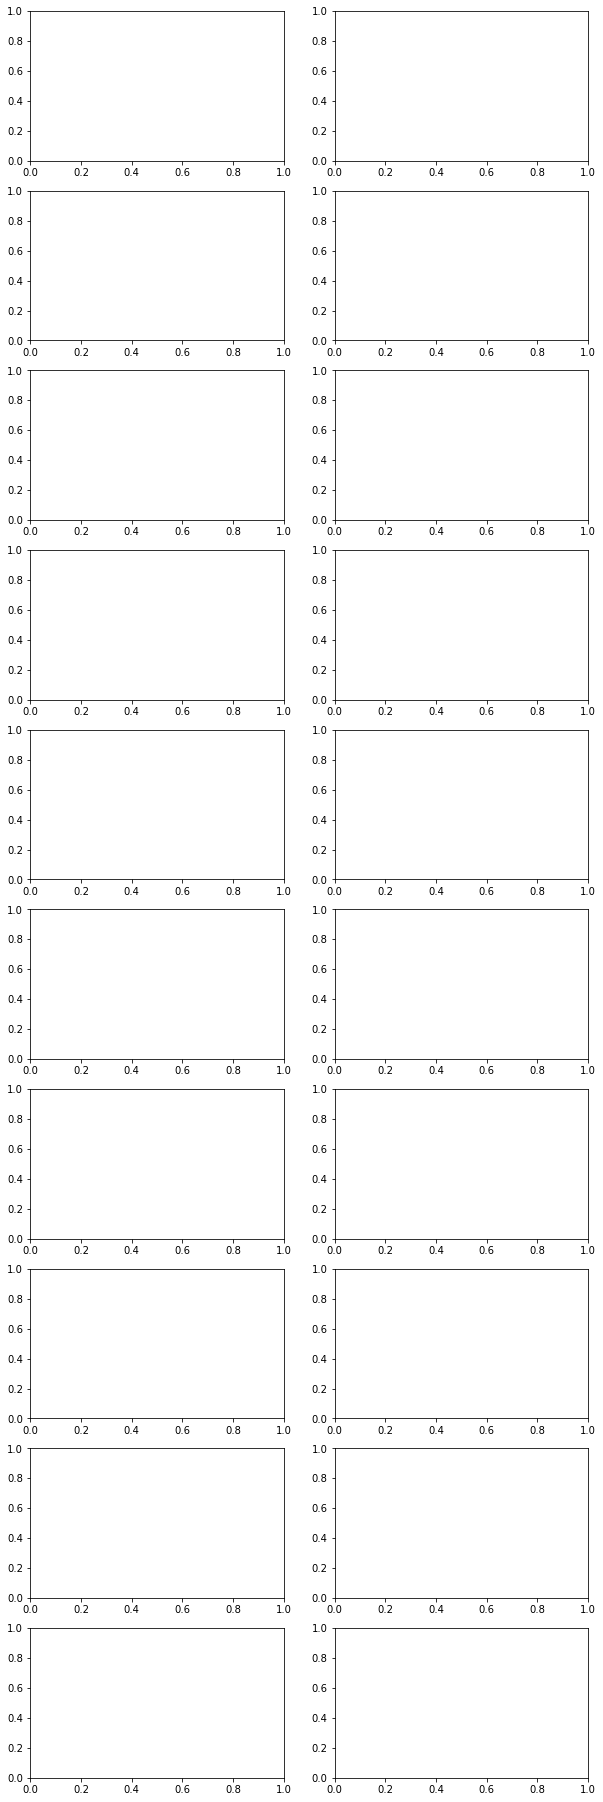

In [ ]:
N_site = 1000

determine_Tc = False
# run nnn simulation
if determine_Tc ==False:
    T_list = np.linspace(0.1,4,100)
    # to determine T_c
else:
    T_list = np.linspace(2.3,3.3,50)


E_mean_list = []
m_mean_list = []
domain_mean_list = []
E_err_list = []
m_err_list = []

# index_for_plot = [0,int(len(T_list)/3),int(2*len(T_list)/3),len(T_list)-1]

num_plots = 20

index_for_plot = (np.arange(0,num_plots)*len(T_list)/(num_plots-1)).astype(int).tolist()
index_for_plot[-1]+=-1

if index_for_plot:
        fig,ax = plt.subplots(int(num_plots/2),2,figsize = (20/2,13/8*num_plots))
count = 0

h=0

for index, T in enumerate(T_list):
    n_max = 10**4*N_site
    if index%5==0:
         print(index)
         
    # if T<0.3:
    #     n_max*=4*10
    if T<0.42:
        n_max*=4*10
    if N_site < 100:
        n_max*=4
    if N_site >1000:
        n_max=5

#    skip=int(n_max/1000)
    num_points = 1000
    skip = int(n_max/num_points)
    n_0=int(n_max/4)

    E,m,final_array=initiate_run(N_site=N_site,T=T,n_max=n_max,num_point=num_points)
    E,m = E/N_site, m/N_site

    if index in index_for_plot:
        axis = ax.flatten()[count]
        axis.scatter(np.arange(len(m))*skip,m,marker='.',label="Magnetisation per site",color="tab:red")
        axis.plot([n_0,n_0],[min(m),max(m)],linestyle="dashed",color="green")
        axis.set_title("T="+str(np.round(T,2)))
        axis.set_xlabel("n")
        axis.set_ylabel("m/N")
        fig.tight_layout()
        count+=1
    # E_mean = np.mean(E[int(n_0/skip):])
    # E_mean_std = np.std(E[int(n_0/skip):])
    m_mean = np.mean(m[int(n_0/skip):])
    m_mean_std = np.std(m[int(n_0/skip):])
#    domain_mean_list.append(np.mean(count_domain_size(final_array)))
    # E_mean_list.append(E_mean)
    m_mean_list.append(m_mean)
    # E_err_list.append(E_mean)
    m_err_list.append(m_mean)

if determine_Tc ==False:
    fig.savefig(".//data//nn_m_plots_"+str(N_site)+".png")
# fig.savefig(".//data//nn_low_temp_test.png")

plt.show()

In [ ]:
if determine_Tc ==False:
    save_array = np.vstack((T_list,m_mean_list,m_err_list)).T
else:
    np.savetxt(".//Data//nn_"+str(N_site)+"_Tc.txt",save_array,header="T,m,m_err")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 50 and the array at index 1 has size 0

ValueError: x and y must be the same size

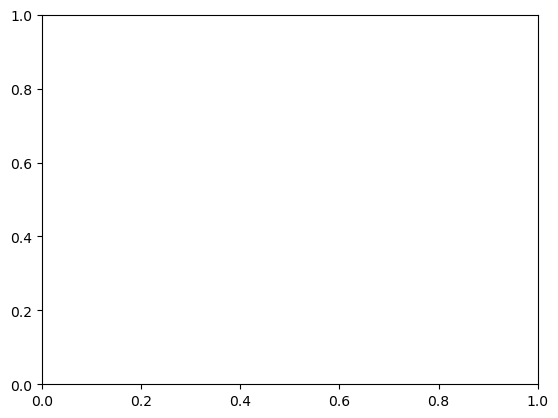

In [ ]:
plt.scatter(T_list,abs(np.array(m_mean_list)))
plt.show()
# plt.savefig("start_order.png")
print(N_site)

0
5
10
15
20
25
30
35
40
45


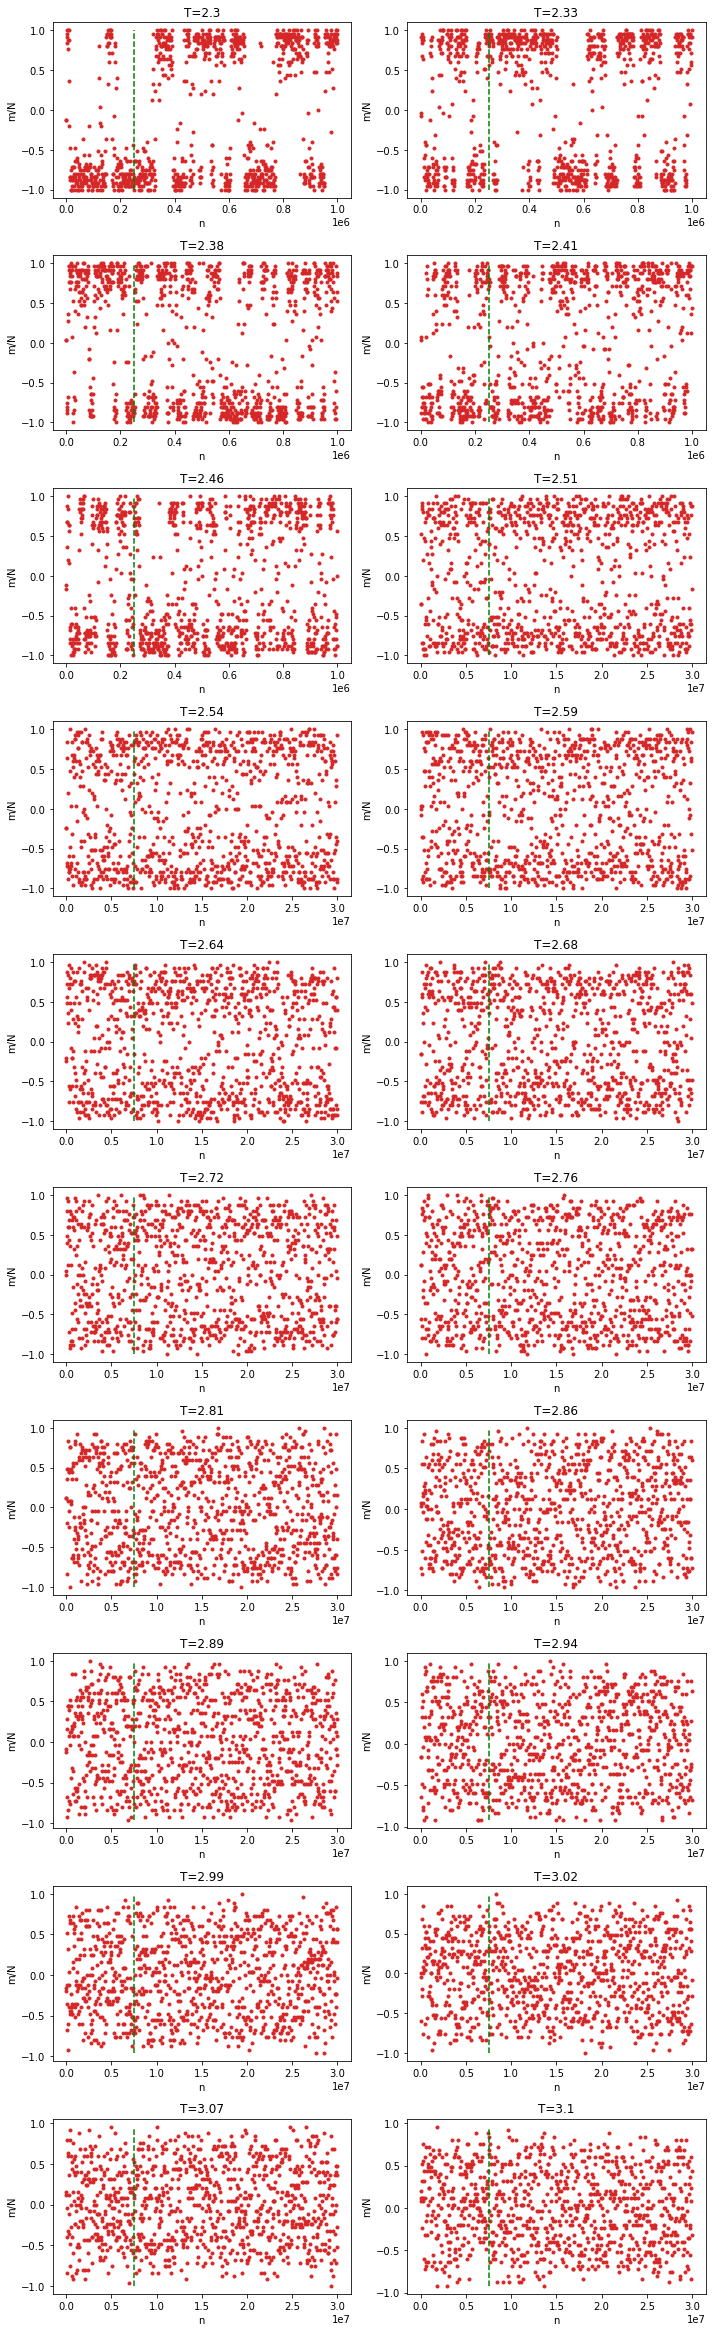

In [24]:
N_site=750

determine_Tc = True
# run nnn simulation
if determine_Tc == False:
    T_list = np.linspace(0.1,4,100)
    # to determine T_c
else:
    T_list = np.linspace(2.3,3.1,50)


E_mean_list = []
m_mean_list = []
domain_mean_list = []
E_err_list = []
m_err_list = []

num_plots = 20

index_for_plot = (np.arange(0,num_plots)*len(T_list)/(num_plots-1)).astype(int).tolist()
index_for_plot[-1]+=-1

if index_for_plot:
        fig,ax = plt.subplots(int(num_plots/2),2,figsize = (20/2,13/8*num_plots))
count = 0

h=0

for index, T in enumerate(T_list):
    n_max = 10**3*N_site
    # if T<= 1.8:
    #     n_max*=1/10
    if T>=2.5 and T<=3.1:
         n_max*=3*10

    if N_site<100:  
         n_max*=20

    num_points = 1000
    skip=int(n_max/num_points)
    n_0=int(n_max/4)

    if index%5==0:
         print(index)

    #E,m,final_array=nnn_sim(N_site,T,n_max=int(n_max),skip=20,h=h)
    E,m,final_array=initiate_run(N_site,T,n_max=int(n_max),num_point=num_points,h=h,nnn=True)
    E,m = E/N_site, m/N_site

    if index in index_for_plot:
        axis = ax.flatten()[count]
        axis.scatter(np.arange(len(m))*skip,m,marker='.',label="Magnetisation per site",color="tab:red")
        axis.plot([n_0,n_0],[min(m),max(m)],linestyle="dashed",color="green")
        axis.set_title("T="+str(np.round(T,2)))
        axis.set_xlabel("n")
        axis.set_ylabel("m/N")
        fig.tight_layout()
        count+=1


#    E_mean = np.mean(E[int(n_0/skip):])
#    E_mean_std = np.std(E[int(n_0/skip):])
    m_mean = np.mean(m[int(n_0/skip):])
    m_mean_std = np.std(m[int(n_0/skip):])
    # domain_mean_list.append(np.mean(count_domain_size(final_array)))
#    E_mean_list.append(E_mean)
    m_mean_list.append(m_mean)
#    E_err_list.append(E_mean)
    m_err_list.append(m_mean)

if determine_Tc == False:
    fig.savefig(".//data//nnn_m_plot_"+str(N_site)+"s.png")
# fig.savefig(".//data//nnn_m_plots.png")
plt.show()

In [25]:
save_array = np.vstack((T_list,m_mean_list,m_err_list)).T
print(np.shape(save_array))
if determine_Tc == False:
    np.savetxt(".//Data//nnn_"+str(N_site)+".txt",save_array,header="T,m,m_err")
else:
    print("Determine T_c")
    np.savetxt(".//Data//nnn_"+str(N_site)+"_Tc.txt",save_array,header="T,m,m_err")


(50, 3)
Determine T_c


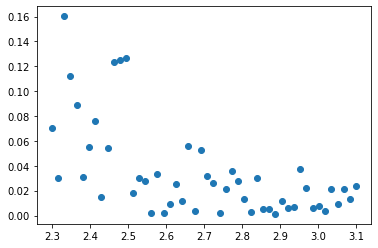

50


In [26]:
plt.scatter(T_list,abs(np.array(m_mean_list)))
plt.show()
print(N_site)

In [11]:
def create_nnn_shuffle(N_site):
    index = np.arange(N_site)
    shuffle = [0]
    for i in range(1,N_site):
        choices = [x for x in index if (x not in shuffle) and (((x-1)%N_site-shuffle[-1]!=0)) and (((x+1)%N_site-shuffle[-1]!=0))]
        choice = random.choice(choices)
        shuffle.append(choice)

    shuffle = np.array(shuffle)
    np.savetxt("nnn_array//shuffle_"+str(N_site)+".txt",shuffle.astype(int))

create_nnn_shuffle(2000)

In [ ]:
def determine_T_c(T_data,m_data):
    slope_list = []
    for i in range(int(len(m_data)-1)):
        a = (m_data[i+1]-m_data[i])/(T_data[i+1]-T_data[i])
        slope_list.append(a)
    slope_list = np.array(slope_list)
    slope , index = max(slope_list),np.argmax(slope_list)
    b = m_data[index]-slope*T_data[index]
    intersect = -b/slope

Testing code

301


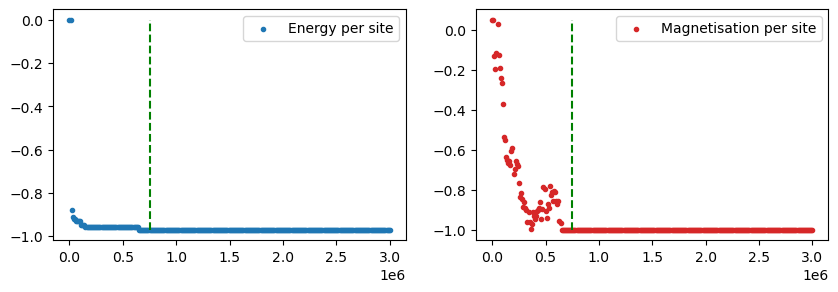

In [20]:
n_0 = n_max/4
print(len(E))
fig,(ax0,ax1) = plt.subplots(1,2,figsize=(10,3))
ax0.scatter(np.arange(len(m))*skip,E,marker='.',label="Energy per site")
ax1.scatter(np.arange(len(m))*skip,m,marker='.',label="Magnetisation per site",color="tab:red")
ax0.plot([n_0,n_0],[min(E),max(E)],linestyle="dashed",color="green")
ax1.plot([n_0,n_0],[min(m),max(m)],linestyle="dashed",color="green")
#ax2.imshow(final_array)
ax0.legend()
ax1.legend()
#fig.tight_layout()
plt.show()
